**Online Retail Dataset : Exploratory Data Analysis**


**#Dataset URL**https://archive.ics.uci.edu/dataset/352/online+retail$0

1. Import Libraries
2. Load Dataset
3. Initial Data Exploration
4. Data Cleaning
5. Statistical Analysis
6. Product Analysis
7. Country Analysis
8. Revenue/month Analysis
9. Customer Analysis
10. Outlier Analysis
11. Correlation Analysis
12. Key Findings
13. Conclusion

In [3]:
!pip install ucimlrepo

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [12]:
from ucimlrepo import fetch_ucirepo
# fetch dataset
online_retail = fetch_ucirepo(id=352)
df=online_retail.data.features
df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [13]:
print(df.shape)

(541909, 6)


In [20]:
print(df.columns)
print("----"*20)
df.info()

Index(['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID',
       'Country'],
      dtype='object')
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  object 
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.8+ MB


In [21]:
#missing value
df.isnull().sum()

,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [22]:
df.duplicated().sum()

np.int64(6007)

In [23]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [26]:
df.columns.tolist()

['Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [27]:
print("Unique Cntrys:", df["Country"].nunique())
print("Unique Prdcts:", df["Description"].nunique())
print("Unique Cstmrs:", df["CustomerID"].nunique())

Unique Cntrys: 38
Unique Prdcts: 4223
Unique Cstmrs: 4372


In [28]:
df["Country"].value_counts().head(10)

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [29]:
df.isnull().sum()


,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [31]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6007


In [32]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [35]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

/tmp/ipykernel_1328/727825892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Revenue"] = df["Quantity"] * df["UnitPrice"]


In [36]:
df["Revenue"]

,Revenue
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34
...,...
541904,10.20
541905,12.60
541906,16.60
541907,16.60


In [37]:
df = df.drop_duplicates()

In [39]:
df = df.dropna(subset=["Description"])

In [40]:
df.shape

(534532, 7)

In [42]:
#any suspicious records
print("Negative quantities:", (df["Quantity"] <= 0).sum())
print("Negative prices:", (df["UnitPrice"] <= 0).sum())

Negative quantities: 9719
Negative prices: 1051


In [43]:
df[df["Quantity"] <= 0][["InvoiceDate", "Description", "Quantity", "UnitPrice", "CustomerID", "Country"]].head(10)

,InvoiceDate,Description,Quantity,UnitPrice,CustomerID,Country
141,12/1/2010 9:41,Discount,-1,27.50,14527.0,United Kingdom
154,12/1/2010 9:49,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0,United Kingdom
235,12/1/2010 10:24,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0,United Kingdom
236,12/1/2010 10:24,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
237,12/1/2010 10:24,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0,United Kingdom
238,12/1/2010 10:24,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,17548.0,United Kingdom
239,12/1/2010 10:24,CHICK GREY HOT WATER BOTTLE,-12,3.45,17548.0,United Kingdom
240,12/1/2010 10:24,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,17548.0,United Kingdom
241,12/1/2010 10:24,PLASTERS IN TIN SKULLS,-24,1.65,17548.0,United Kingdom
939,12/1/2010 12:38,JAM MAKING SET WITH JARS,-6,4.25,17897.0,United Kingdom


In [46]:
#cleaner sales_data
sales_df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
print(sales_df.shape)

(524231, 7)


In [47]:
sales_df.isnull().sum()

,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,131614
Country,0
Revenue,0


In [48]:
#consumerid has missing value :131614
sales_df.dtypes

,0
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object
Revenue,float64


In [49]:
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

In [51]:
sales_df.dtypes

,0
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object
Revenue,float64


In [52]:
#EDA
sales_df[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,524231.000000,524231.000000,524231.000000
mean,10.626808,3.920408,20.289201
std,156.375832,36.114874,271.857821
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.950000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [53]:
#products are sold most frequently
top_products = (
    sales_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48349
WHITE HANGING HEART T-LIGHT HOLDER,37869
POPCORN HOLDER,36745
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30737


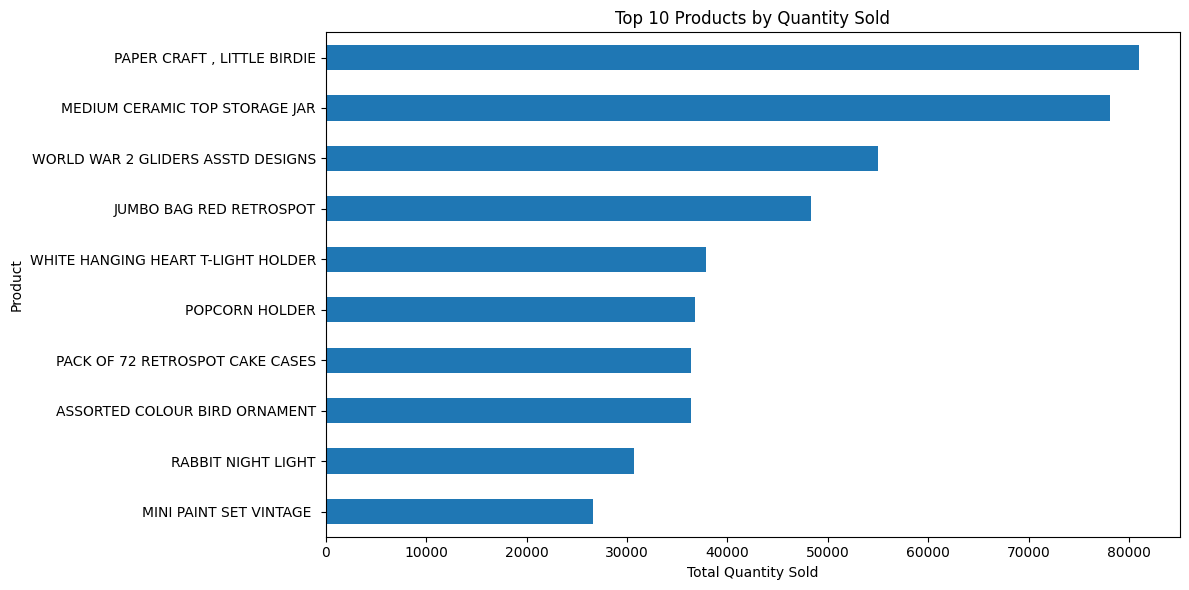

In [57]:
plt.figure(figsize=(12, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

In [58]:
country_sales = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales

,Revenue
Country,
United Kingdom,8995897.834
Netherlands,285446.340
EIRE,283140.520
Germany,228660.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


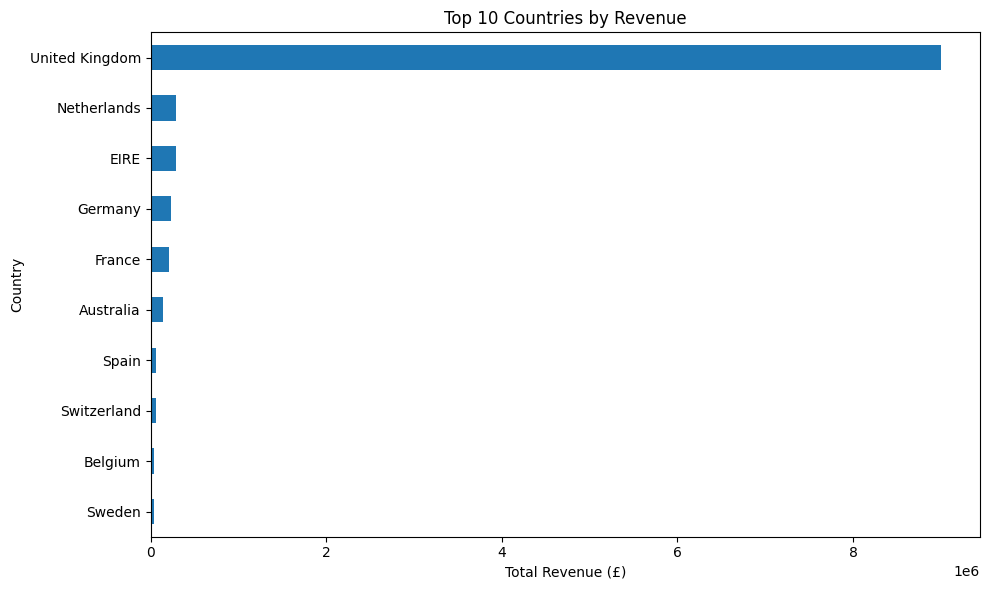

In [59]:
plt.figure(figsize=(10, 6))

country_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()

plt.show()

In [60]:
sales_df["YearMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    sales_df.groupby("YearMonth")["Revenue"]
    .sum()
)

monthly_sales

,Revenue
YearMonth,
2010-12,820515.290
2011-01,689673.220
2011-02,522289.220
2011-03,715491.910
2011-04,536509.771
2011-05,768148.040
2011-06,759952.300
2011-07,716872.781
2011-08,757831.380


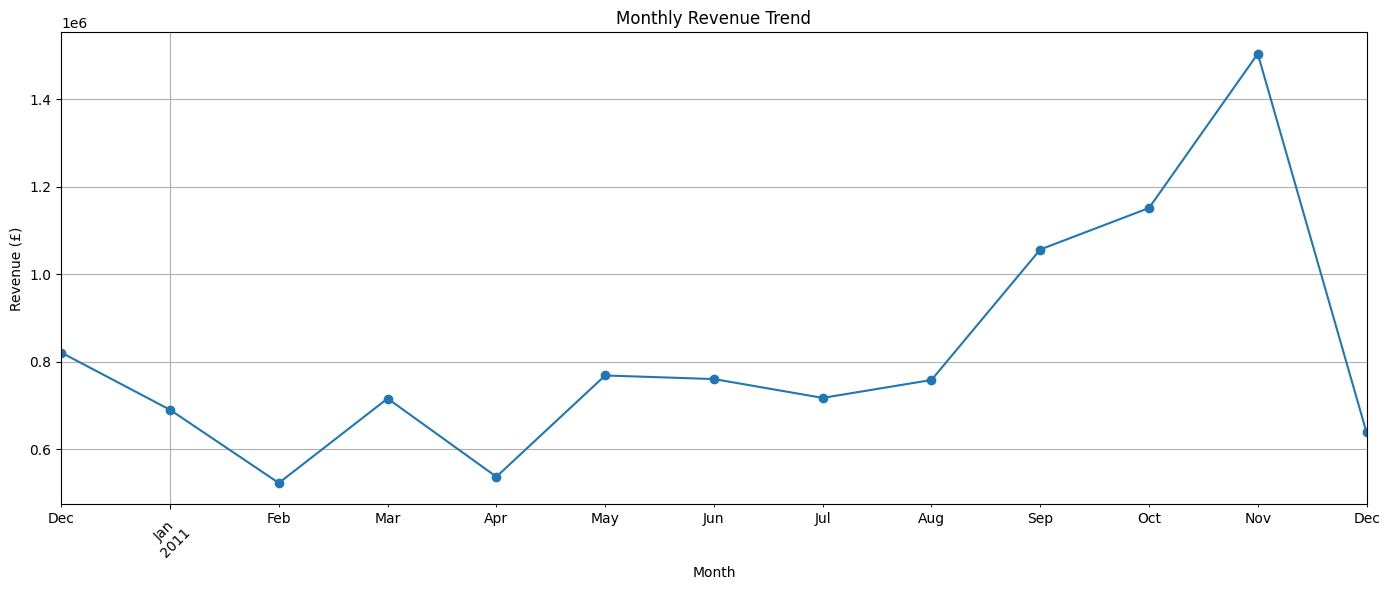

In [61]:
plt.figure(figsize=(14, 6))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [63]:
print("Highest Revenue Month:")
print(monthly_sales.idxmax(), " £", round(monthly_sales.max(), 2))

print("\nLowest Revenue Month:")
print(monthly_sales.idxmin(), " £", round(monthly_sales.min(), 2))

Highest Revenue Month:
2011-11  £ 1503807.07

Lowest Revenue Month:
2011-02  £ 522289.22


In [64]:
#customerr analysis
customer_sales = (
    sales_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_sales

,Revenue
CustomerID,
14646.0,280206.02
18102.0,258741.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80673.24


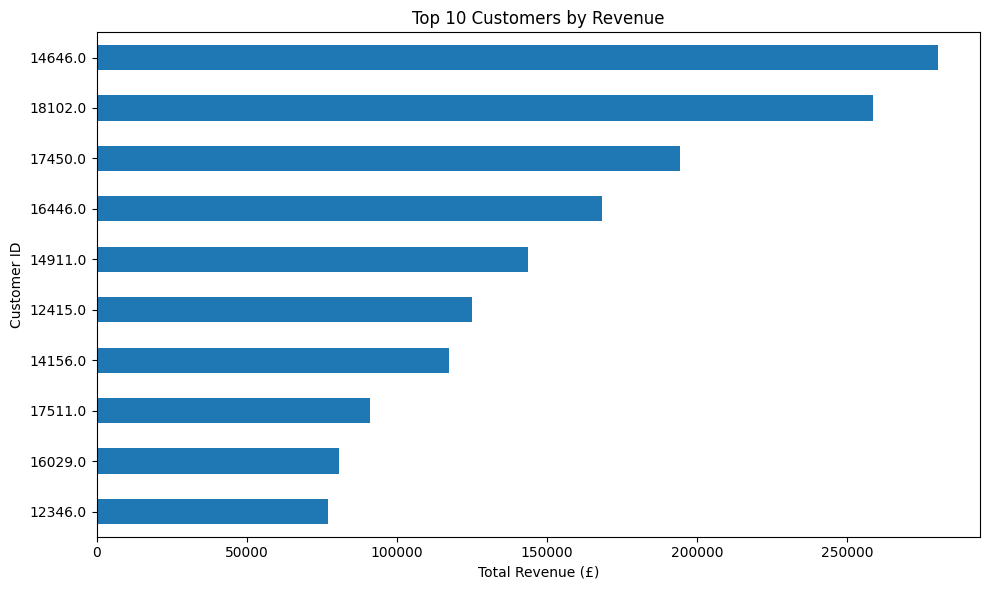

In [65]:
plt.figure(figsize=(10, 6))

customer_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.show()

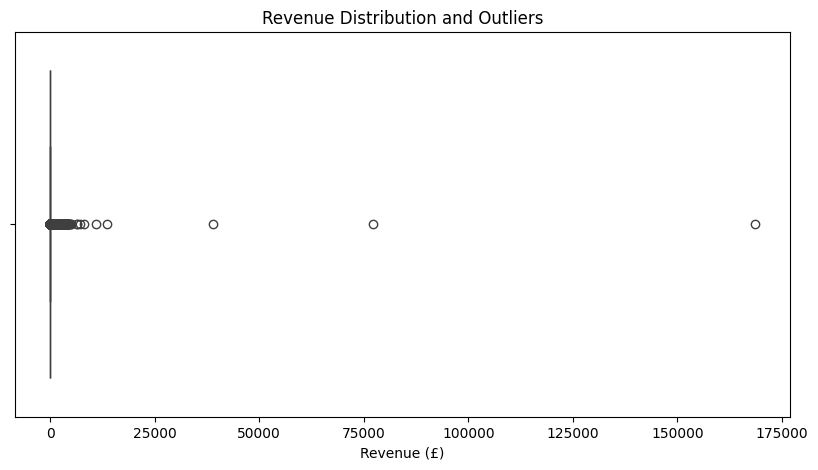

In [66]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=sales_df["Revenue"])

plt.title("Revenue Distribution and Outliers")
plt.xlabel("Revenue (£)")

plt.show()

In [67]:
Q1 = sales_df["Revenue"].quantile(0.25)
Q3 = sales_df["Revenue"].quantile(0.75)
#Inter Quartile Range
IQRange = Q3 - Q1

lower_limit = Q1 - 1.5 * IQRange
upper_limit = Q3 + 1.5 * IQRange

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQRange)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 3.9
Q3: 17.700000000000003
IQR: 13.800000000000002
Lower Limit: -16.800000000000004
Upper Limit: 38.400000000000006


In [69]:
#Outliers count
outliers = sales_df[sales_df["Revenue"] > upper_limit]

print("Number of revenue outliers:", len(outliers))
print("Percentage of revenue outliers:", round(len(outliers) / len(sales_df) * 100, 2), "%")

Number of revenue outliers: 42621
Percentage of revenue outliers: 8.13 %


In [71]:
#big transactions
outliers[["Description", "Quantity", "UnitPrice", "Revenue", "Country"]].sort_values(
    "Revenue", ascending=False
).head(10)

,Description,Quantity,UnitPrice,Revenue,Country
540421,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,United Kingdom
61619,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,United Kingdom
222680,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,United Kingdom
15017,AMAZON FEE,1,13541.33,13541.33,United Kingdom
299982,Adjust bad debt,1,11062.06,11062.06,United Kingdom
173382,POSTAGE,1,8142.75,8142.75,United Kingdom
348325,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,United Kingdom
52711,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
160546,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,United Kingdom
421601,RABBIT NIGHT LIGHT,2400,2.08,4992.00,Netherlands


In [72]:
customer_sales = (
    sales_df.dropna(subset=["CustomerID"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_sales

,Revenue
CustomerID,
14646.0,280206.02
18102.0,258741.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80673.24


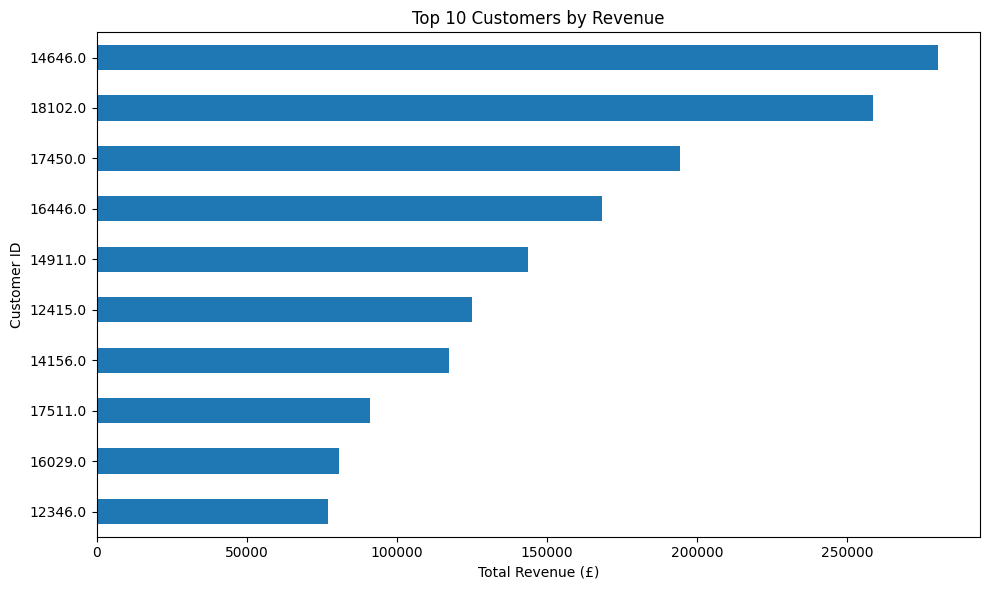

In [73]:
plt.figure(figsize=(10, 6))

customer_sales.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.show()

In [75]:
#Analysis for correlation
correlation = sales_df[["Quantity", "UnitPrice", "Revenue"]].corr()
correlation

,Quantity,UnitPrice,Revenue
Quantity,1.000000,-0.003784,0.907405
UnitPrice,-0.003784,1.000000,0.137385
Revenue,0.907405,0.137385,1.000000


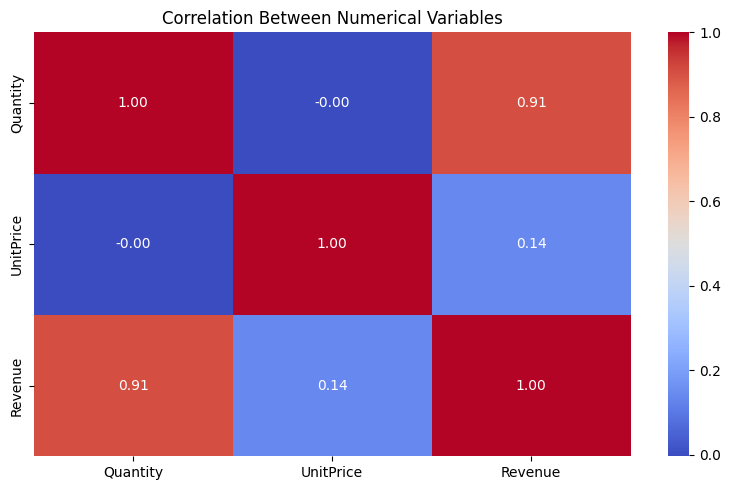

In [76]:
plt.figure(figsize=(8, 5))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()

plt.show()

In [77]:
print("Total Revenue: £", round(sales_df["Revenue"].sum(), 2))
print("Total Units Sold:", sales_df["Quantity"].sum())
print("Unique Products:", sales_df["Description"].nunique())
print("Unique Countries:", sales_df["Country"].nunique())
print("Unique Customers:", sales_df["CustomerID"].nunique())
print("Average Transaction Revenue: £", round(sales_df["Revenue"].mean(), 2))

Total Revenue: £ 10636228.14
Total Units Sold: 5570902
Unique Products: 4026
Unique Countries: 38
Unique Customers: 4338
Average Transaction Revenue: £ 20.29


In [78]:
#TOP REVENUE PRODCTS
top_revenue_prdcts = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_revenue_prdcts

,Revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106216.83
PARTY BUNTING,99435.91
JUMBO BAG RED RETROSPOT,94068.95
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78083.88
Manual,77752.82


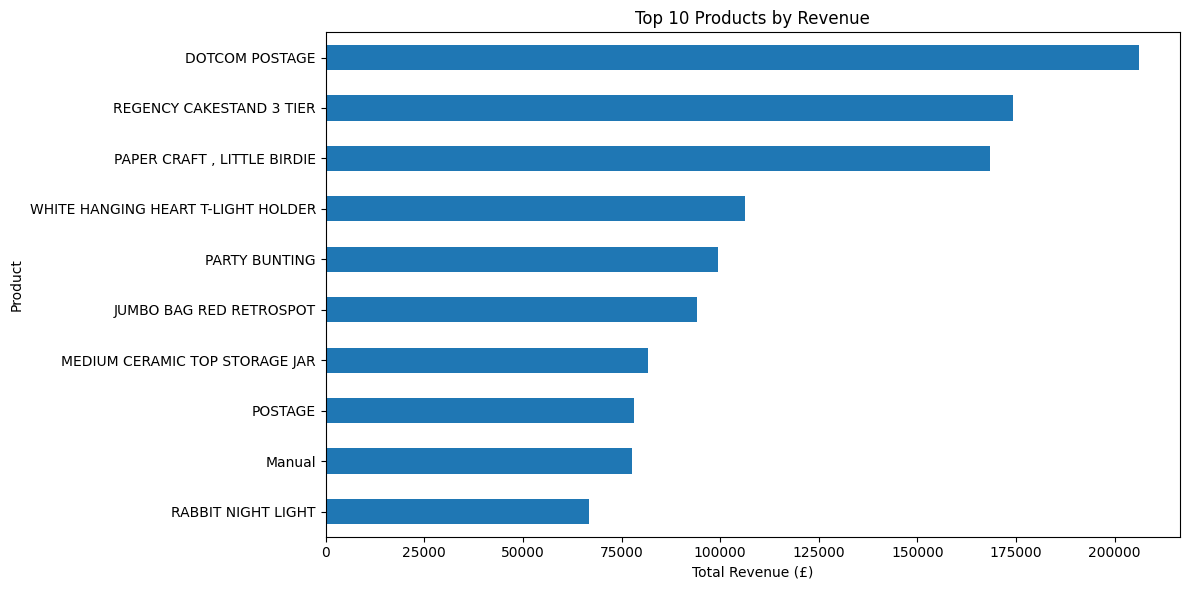

In [79]:
plt.figure(figsize=(12, 6))

top_revenue_prdcts.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

#FINAL DATA VALIDATION

In [86]:
print("Final Dataset Shape:", sales_df.shape)
print("Missing Values:")
print(sales_df.isnull().sum())

Final Dataset Shape: (524231, 8)
Missing Values:
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     131614
Country             0
Revenue             0
YearMonth           0
dtype: int64


**# KEY FINDINGS**

After exploring the Online Retail dataset, I found a few interesting patterns in the sales data:

1. The original dataset had 541,909 records. After removing duplicate entries, records with missing product descriptions, and transactions with invalid quantity or price values, 524,231 records were used for the main analysis.

2. PAPER CRAFT, LITTLE BIRDIE turned out to be the most sold product in terms of quantity, with 80,995 units sold.

3. Sales were not the same throughout the year. There were some ups and downs in the monthly revenue, but sales increased noticeably towards the end of the year. November 2011 had the highest monthly revenue.

4. Customer spending was also quite uneven. Some customers contributed much more revenue than others. Customer 14646 was the top customer in terms of revenue, with around £280,206.

5. I also noticed some very large transaction values while checking for outliers. These were not removed automatically because they could be genuine bulk purchases rather than errors in the data.

7. One interesting observation was that the products sold in the largest quantities were not always the products generating the most revenue. This shows that looking only at sales volume does not give the complete picture of product performance.

# Conclusion

This analysis helped me understand how raw retail transaction data can be cleaned and converted into useful business information.

The dataset had several issues, such as duplicate records, missing values, negative quantities, and some unusual transaction values. After cleaning the data and examining these issues, I was able to look at sales from different angles, including products, customers, countries, and monthly trends.

One of the main things I noticed was the strong contribution of the United Kingdom to the overall revenue. I also found that a relatively small number of products and customers contributed a large part of the sales.

Overally, this project gave me practical experience with data cleaning, grouping data, identifying outliers, and presenting the results through visualizations. It also showed me that looking at the same dataset from different perspectives can reveal insights that are not obvious from the raw data alone.